# Position-dependent photon fields / 1 - Generating a spatially-scaled power-law photon field

This notebook extends the custom-photon-field example
(`doc/pages/example_notebooks/custom_photonfield/custom-photon-field.ipynb`) to a
**position-dependent** photon field. It first reproduces the homogeneous `PowerlawPhotonField` from
that example, then modulates it in space with a softened $1/r$ profile and verifies the result.

As in the custom-photon-field example, **two** photon-field classes are involved for every model: one
that lives in the CRPropa-data repository and produces the tabulated files (interaction rates,
densities), and one that lives in CRPropa and is used during propagation. Here the second class is the
built-in `TabularSpatialPhotonField`.

## Physics background

High-energy photons are attenuated by pair production on the soft radiation field,
$\gamma + \gamma_{\rm bg} \to e^+ e^-$. Its kinematic threshold $E_\gamma\,\epsilon \gtrsim (m_e c^2)^2$
means that for the target field used here ($\epsilon$ up to $\sim 10^3$ eV) absorption switches on
around a TeV.

The Galactic interstellar radiation field is concentrated toward the Galactic centre and the disk, so
the attenuation depends on **where** the photon is, not only on its energy. `TabularSpatialPhotonField`
captures this by storing one comoving density spectrum $\mathrm{d}n/\mathrm{d}\epsilon$ [1/m³/J] **per
spatial grid node**; a query returns the nearest node's spectrum, interpolated in energy. The redshift
dependence is dropped, since the application is Galactic.

## Setup

The CRPropa-data repository provides the base classes (`photonField`) and the table generators
(`calc_all`). Set `crpropa_data_path` below to your local CRPropa-data checkout. The share folder is
taken from `crp.getDataPath("")`, so the tables generated here are written exactly where CRPropa reads
them during propagation.

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

import crpropa as crp
import numpy as np
from crpropa import TeV, Vector3d, ccm, eV, kpc

# path to the local CRPropa-data repository checkout (adjust to your installation)
crpropa_data_path = "/home/grindegreen/miniconda3/envs/crpropa-position/CRPropa3-data/"
# share folder this CRPropa build reads its tables from; derived automatically so the
# tables generated below land exactly where propagation looks them up.
crpropa_share_path = crp.getDataPath("")
sys.path.append(crpropa_data_path)

import matplotlib.pyplot as plt

import calc_all as ca  # CRPropa-data: interaction-table generators
import photonField as pf  # CRPropa-data: base photon-field classes

## 1. Define the homogeneous photon field (CRPropa-data)

The starting point is the single power law with exponential cutoffs from the custom-photon-field
example, $\mathrm{d}n/\mathrm{d}\epsilon \propto (\epsilon/\mathrm{eV})^{\alpha}$ on
$[\epsilon_{\min},\epsilon_{\max}]$. The class below is taken verbatim from that example; it inherits
from the CRPropa-data base class and provides the mandatory `name`, `info`, `redshift`, the energy
grid, the density, and `getDensity`/`getEmin`/`getEmax`.

In [2]:
class PowerlawPhotonField(pf.PhotonField):

    def __init__(self, norm=1e28, slope=-2.5, eMin=1e-4 * eV, eMax=1e3 * eV):
        """Power law with exponential cutoffs; norm is n(eps = 1 eV)."""
        super(PowerlawPhotonField, self).__init__()
        self.name = "PowerlawPhotonField"
        self.info = (
            "Single power law photon field with exponential cutoffs at both ends."
        )
        self.redshift = None
        self.norm = norm
        self.slope = slope
        self.eMin = eMin
        self.eMax = eMax
        self.energy = np.logspace(np.log10(self.eMin), np.log10(self.eMax), 101) / eV
        self.photonDensity = self.getDensity(self.energy * eV) / (eV**-1 * ccm**-1)

    def getDensity(self, eps, z=0):
        """Comoving spectral number density dn/deps [1/m^3/J] at energy eps [J]."""
        if type(eps) == np.ndarray:
            return np.array([self.getDensity(_eps, z) for _eps in eps])
        if (eps >= self.eMin) & (eps <= self.eMax):
            return self.norm * (eps / eV) ** self.slope
        else:
            return 0.0

    def getEmin(self):
        return self.eMin

    def getEmax(self):
        return self.eMax


field = PowerlawPhotonField()
print("field :", field.name)
print("range :", f"{field.getEmin()/eV:.1e} .. {field.getEmax()/eV:.1e} eV")

field : PowerlawPhotonField
range : 1.0e-04 .. 1.0e+03 eV


### Plot the field
The power-law field is shown as $\epsilon^2\,\mathrm{d}n/\mathrm{d}\epsilon$, with the cosmic
microwave background for comparison (as in the custom-photon-field example).

/home/grindegreen/miniconda3/envs/crpropa-position/CRPropa3-data/photonField.py:79: RuntimeWarning: overflow encountered in expm1
  return 8*np.pi / c_light**3 / h_planck**3 * eps**2 / np.expm1(eps / (k_boltzmann * self.T_CMB))


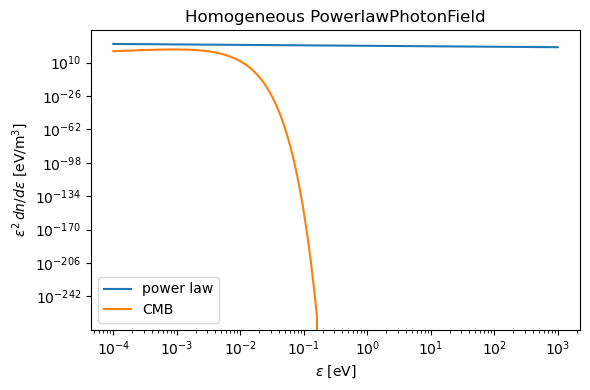

In [3]:
field_cmb = pf.CMB()
eps = np.logspace(-4, 3, 300) * eV
c = eps**2 / eV**2
plt.figure(figsize=(6, 4))
plt.plot(eps / eV, c * field.getDensity(eps), label="power law")
plt.plot(eps / eV, c * field_cmb.getDensity(eps), label="CMB")
plt.loglog()
plt.legend()
plt.xlabel(r"$\epsilon$ [eV]")
plt.ylabel(r"$\epsilon^2\,dn/d\epsilon$ [eV/m$^3$]")
plt.title("Homogeneous PowerlawPhotonField")
plt.tight_layout()
plt.show()

## 2. Generate the interaction tables (CRPropa-data)

`calc_all` precomputes the tables for all photon-dependent processes. This step is expensive
(~15 minutes). It writes into `./data`, which is then copied into the CRPropa share folder. The cell
is guarded so it only runs if the base tables are not already present; delete the guard to force a
regeneration.

In [4]:
base_present = (
    Path(crpropa_share_path, "Scaling", f"{field.name}_photonEnergy.txt").exists()
    and Path(crpropa_share_path, "EMPairProduction", f"rate_{field.name}.txt").exists()
)

if base_present:
    print(
        "Base tables already present in the share folder; skipping the (~15 min) generation."
    )
else:
    # 2. generate the tables
    with warnings.catch_warnings():  # density ~ 0 outside the band -> divide-by-zero warnings
        warnings.simplefilter("ignore")
        ca.EM_processes([field])
        ca.photon_fields([field])
    # 3. copy the generated tables into the share folder
    subprocess.run(["cp", "-a", "./data/.", crpropa_share_path])
    print("Generated and copied base tables for", field.name)

Base tables already present in the share folder; skipping the (~15 min) generation.


## 3. Scale the field in space

The homogeneous field is turned into a position-dependent one by multiplying its density by a
softened central profile
$$f(r) = \frac{r_s}{r + r_s},\qquad r_s = 0.2\ \mathrm{kpc},$$
maximal at the centre ($f=1$) and falling outward. Because pair production is **linear in the target
photon density**, the interaction rate scales by the same factor $f$.

### On-disk layout
A `TabularSpatialPhotonField` named `NAME` stores one file per grid node:

```
Scaling/NAME/photonEnergy/NAME_node_<-x>_<y>_<z>.txt
Scaling/NAME/photonDensity/NAME_node_<-x>_<y>_<z>.txt
EMPairProduction/NAME/Rate/rate_NAME_node_...
EMPairProduction/NAME/CumulativeRate/cdf_NAME_node_...
```

Two conventions are imposed by the reader and must be matched on write:

1. **Coordinates are encoded in the filename**, split on `_`; the reader applies $x=-\,\mathrm{stod}$,
   so files store $-x$. Consequently the field name must contain **no `_`**, or the tokens shift.
2. **Energy and density files are read reversed** (each line is inserted at the front of the array,
   matching the high$\to$low ordering of the CRPropa export). The base table is stored low$\to$high,
   so it is written reversed here; after the reader reverses it again the in-memory array is
   increasing, as the interpolation requires. Without this, `getPhotonDensity` returns 0 everywhere.

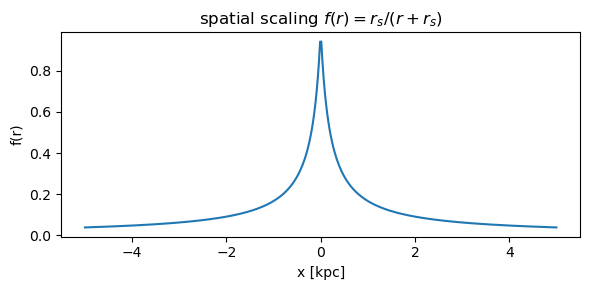

In [5]:
SPATIAL_FIELD = "PowerlawPhotonFieldTest1R"  # no '_' in the name
assert "_" not in SPATIAL_FIELD
GRID_X_KPC = np.linspace(-5.0, 5.0, 21)  # nodes along x (odd count keeps a node at x=0)


def f_soft_1_over_r(x, y=0.0, z=0.0, A=1.0, r_s=0.2):
    r = np.sqrt(x * x + y * y + z * z)
    return A * r_s / (r + r_s)


xx = np.linspace(-5, 5, 400)
plt.figure(figsize=(6, 3))
plt.plot(xx, f_soft_1_over_r(xx))
plt.xlabel("x [kpc]")
plt.ylabel("f(r)")
plt.title(r"spatial scaling $f(r)=r_s/(r+r_s)$")
plt.tight_layout()
plt.show()

### Writers
The energy and density files are written **reversed**; the rate and CDF files keep their order (their
reader does not reverse). Every file scales by $f$ except the energy grid.

In [6]:
def node_suffix(x, y, z):
    # store -x because the reader applies x = -stod(token)
    return f"node_{-x:.8g}_{y:.8g}_{z:.8g}"


def data_lines(path):
    return [l for l in open(path) if l.strip() and not l.lstrip().startswith("#")]


def write_reversed(src, dst, scale=1.0):
    """energy/density: reverse line order; optionally scale every column."""
    with open(dst, "w") as fout:
        for line in reversed(data_lines(src)):
            vals = [float(v) * scale for v in line.split()]
            fout.write(" ".join(f"{v:.16e}" for v in vals) + "\n")


def scale_rate_like(src, dst, scale):
    """rate/cdf: keep order and header; scale all columns except the first
    (log10 E, or the s-grid row of a CDF file)."""
    seen = False
    with open(src) as fin, open(dst, "w") as fout:
        for line in fin:
            s = line.strip()
            if not s or s.startswith("#"):
                fout.write(line)
                continue
            parts = s.split()
            if not seen and len(parts) > 2:  # CDF s-grid row: keep unchanged
                fout.write(line)
                seen = True
                continue
            seen = True
            rest = [float(v) * scale for v in parts[1:]]
            fout.write(parts[0] + " " + " ".join(f"{v:.16e}" for v in rest) + "\n")

## 4. Generate the spatial field

One file per node, scaled by `f(node)`. The CDF files must exist (the position-dependent
`EMPairProduction` constructor reads them) even though the absorption-only runs in the later notebooks
never sample them.

In [7]:
DATA = Path(crpropa_share_path)
be = DATA / "Scaling" / f"{field.name}_photonEnergy.txt"
bd = DATA / "Scaling" / f"{field.name}_photonDensity.txt"
br = DATA / "EMPairProduction" / f"rate_{field.name}.txt"
bc = DATA / "EMPairProduction" / f"cdf_{field.name}.txt"

oe = DATA / "Scaling" / SPATIAL_FIELD / "photonEnergy"
od = DATA / "Scaling" / SPATIAL_FIELD / "photonDensity"
orr = DATA / "EMPairProduction" / SPATIAL_FIELD / "Rate"
oc = DATA / "EMPairProduction" / SPATIAL_FIELD / "CumulativeRate"
for d in (oe, od, orr, oc):
    d.mkdir(parents=True, exist_ok=True)

for x in GRID_X_KPC:
    f = f_soft_1_over_r(x)
    suf = node_suffix(x, 0.0, 0.0)
    write_reversed(be, oe / f"{SPATIAL_FIELD}_{suf}.txt")  # energy:  reversed, unscaled
    write_reversed(
        bd, od / f"{SPATIAL_FIELD}_{suf}.txt", scale=f
    )  # density: reversed, x f
    scale_rate_like(br, orr / f"rate_{SPATIAL_FIELD}_{suf}.txt", f)  # rate:    x f
    scale_rate_like(bc, oc / f"cdf_{SPATIAL_FIELD}_{suf}.txt", f)  # cdf:     x f

print(f"generated {len(GRID_X_KPC)} nodes for {SPATIAL_FIELD}")

generated 21 nodes for PowerlawPhotonFieldTest1R


## 5. Check the implementation

### Density gradient
The density at the centre ($r=0$, $f=1$) over the density at $r=5$ kpc should equal
$$\frac{f(0)}{f(5)}=\frac{5+r_s}{r_s}=\frac{5.2}{0.2}=26 .$$

density(0)/density(5 kpc) = 26.00  (expected 26.00)


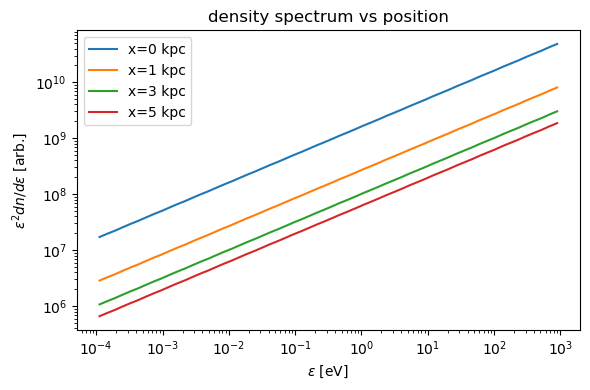

In [8]:
field_sp = crp.TabularSpatialPhotonField(SPATIAL_FIELD)
Eq = 1e-20  # J, inside the band
d0 = field_sp.getPhotonDensity(Eq, 0, Vector3d(0, 0, 0))
d5 = field_sp.getPhotonDensity(Eq, 0, Vector3d(5 * kpc, 0, 0))
print(f"density(0)/density(5 kpc) = {d0/d5:.2f}  (expected {5.2/0.2:.2f})")

Eg = (
    np.logspace(
        np.log10(field_sp.getMinimumPhotonEnergy(0) / eV) + 0.05,
        np.log10(field_sp.getMaximumPhotonEnergy(0) / eV) - 0.05,
        60,
    )
    * eV
)
plt.figure(figsize=(6, 4))
for x in [0, 1, 3, 5]:
    dn = [field_sp.getPhotonDensity(e, 0, Vector3d(x * kpc, 0, 0)) for e in Eg]
    plt.loglog(Eg / eV, (Eg / eV) ** 2 * np.array(dn), label=f"x={x} kpc")
plt.xlabel(r"$\epsilon$ [eV]")
plt.ylabel(r"$\epsilon^2 dn/d\epsilon$ [arb.]")
plt.legend()
plt.title("density spectrum vs position")
plt.tight_layout()
plt.show()

### Interaction rate
Passing the spatial field to `EMPairProduction` builds the position-dependent interaction rate
(nearest-node lookup via a KD-tree). The process rate at a position should equal the base rate times
$f(r)$ of the nearest node.

In [9]:
rates = crp.EMPairProduction(field_sp, False, 0.0).getInteractionRates()
E = 10 * TeV
r0 = rates.getProcessRate(E, Vector3d(0, 0, 0))
print(f"{'x[kpc]':>7}{'f(r)':>9}{'rate/rate0':>12}")
for x in [0, 1, 2, 5]:
    r = rates.getProcessRate(E, Vector3d(x * kpc, 0, 0))
    print(f"{x:7.1f}{f_soft_1_over_r(x):9.4f}{r/r0:12.4f}")

 x[kpc]     f(r)  rate/rate0
    0.0   1.0000      1.0000
    1.0   0.1667      0.1667
    2.0   0.0909      0.0909
    5.0   0.0385      0.0385


## 6. Notes and limitations

- A spatial field is one density and rate table **per node**; queries use nearest node plus energy
  interpolation. The density gradient (= 26) and the rate ratios (= $f$) confirm the generation is
  correct.
- The field name must contain **no `_`**, and the energy/density files must be written **reversed**.
- During propagation the step size must resolve the spatial variation ($\ll r_s$); this is examined
  in notebook 2.

Notebook 2 uses this field: it propagates a power-law gamma-ray source through the homogeneous and the
$1/r$-scaled field, compares the surviving spectrum against an analytic reference, and then checks how
the result converges as the spatial grid is refined.